In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [5]:
%pip install -q dagshub mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 95.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub
import os
import warnings
warnings.filterwarnings('ignore')
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

# Download latest version
path = kagglehub.competition_download('ieee-fraud-detection')

os.environ['MLFLOW_TRACKING_USERNAME'] = 'aband22'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '7ee83e7342830ad0ab1acadf4bf79200db411131'

dagshub.init(repo_owner='aband22', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)
mlflow.set_experiment("RandomForest_Training")

print("MLflow Connected ✓")
print("Tracking URI:", mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=2437bf4a-76c5-429e-80e2-501bb10e66c1&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a9ae2df0dd5bdf10fe47b4c01f4f1a837b4abc0ee5c8ce2bc17ac45c656566ba




Accessing as aband22

Initialized MLflow to track repo "aband22/IEEE-CIS-Fraud-Detection"

Repository aband22/IEEE-CIS-Fraud-Detection initialized!

MLflow Connected ✓
Tracking URI: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow


In [7]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
test_transaction  = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_identity     = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test  = pd.merge(test_transaction,  test_identity,  on='TransactionID', how='left')

# Keep raw copies for final pipeline
raw_train = train.copy()
raw_test  = test.copy()

TARGET = 'isFraud'
y = train[TARGET].copy()

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Fraud rate :", round(train[TARGET].mean() * 100, 3), "%")

Train shape: (590540, 434)
Test shape : (506691, 433)
Fraud rate : 3.499 %


In [8]:
with mlflow.start_run(run_name="RandomForest_Cleaning"):

    original_cols = train.shape[1]

    # Drop target and ID
    train.drop(columns=[TARGET, 'TransactionID'], inplace=True)
    test.drop(columns=['TransactionID'], inplace=True)

    # 1. Drop columns with >50% missing
    null_pct       = train.isnull().mean()
    high_null_cols = null_pct[null_pct > 0.5].index.tolist()
    train.drop(columns=high_null_cols, inplace=True)
    test.drop(columns=[c for c in high_null_cols if c in test.columns], inplace=True)
    print(f"Dropped high-null cols : {len(high_null_cols)}")

    # 2. Drop constant columns
    const_cols = [c for c in train.columns if train[c].nunique() <= 1]
    train.drop(columns=const_cols, inplace=True)
    test.drop(columns=[c for c in const_cols if c in test.columns], inplace=True)
    print(f"Dropped constant cols  : {len(const_cols)}")

    # 3. Label encode categoricals
    cat_cols = train.select_dtypes(include='object').columns.tolist()
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
        classes    = set(le.classes_)
        test[col]  = le.transform(
            test[col].astype(str).apply(lambda x: x if x in classes else le.classes_[0])
        )
        label_encoders[col] = le
    print(f"Label encoded cols     : {len(cat_cols)}")

    # 4. Fill remaining NaNs with median
    num_cols = train.select_dtypes(include=np.number).columns.tolist()
    medians  = train[num_cols].median()
    train[num_cols] = train[num_cols].fillna(medians)
    test[num_cols]  = test[num_cols].fillna(medians)

    # Log
    mlflow.log_param("null_threshold",      0.5)
    mlflow.log_param("nan_strategy",        "median")
    mlflow.log_param("cat_encoding",        "label_encoding")
    mlflow.log_metric("original_cols",      original_cols)
    mlflow.log_metric("dropped_null_cols",  len(high_null_cols))
    mlflow.log_metric("dropped_const_cols", len(const_cols))
    mlflow.log_metric("label_encoded_cols", len(cat_cols))
    mlflow.log_metric("remaining_cols",     train.shape[1])
    mlflow.log_metric("train_rows",         train.shape[0])
    mlflow.log_metric("fraud_rate_pct",     round(y.mean() * 100, 3))

    print(f"\nOriginal cols  : {original_cols}")
    print(f"Remaining cols : {train.shape[1]}")

Dropped high-null cols : 214
Dropped constant cols  : 0
Label encoded cols     : 9

Original cols  : 434
Remaining cols : 218
🏃 View run RandomForest_Cleaning at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/a19a68a2d0804910a7ff3063772037fa
🧪 View experiment at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


Feature Engineering

In [9]:
with mlflow.start_run(run_name="RandomForest_Feature_Engineering"):

    n_before = train.shape[1]

    # 1. Time features
    for df in [train, test]:
        df['hour']        = (df['TransactionDT'] / 3600) % 24
        df['day_of_week'] = (df['TransactionDT'] / (3600 * 24)) % 7
        df['week']        = (df['TransactionDT'] / (3600 * 24 * 7)) % 52

    # 2. Transaction amount features
    for df in [train, test]:
        df['TransactionAmt_log']     = np.log1p(df['TransactionAmt'])
        df['TransactionAmt_cents']   = df['TransactionAmt'] - df['TransactionAmt'].astype(int)
        df['TransactionAmt_isround'] = (df['TransactionAmt_cents'] == 0).astype(int)

    # 3. Frequency encoding
    for col in ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2']:
        if col in train.columns:
            freq_map          = train[col].value_counts().to_dict()
            train[f'{col}_freq'] = train[col].map(freq_map)
            test[f'{col}_freq']  = test[col].map(freq_map).fillna(0)

    # 4. Aggregation features
    for col in ['card1', 'card2']:
        if col in train.columns:
            grp = train.groupby(col)['TransactionAmt'].agg(['mean', 'std']).reset_index()
            grp.columns = [col, f'TransactionAmt_mean_by_{col}', f'TransactionAmt_std_by_{col}']
            train = train.merge(grp, on=col, how='left')
            test  = test.merge(grp,  on=col, how='left')

    # 5. Email domain suffix
    if 'P_emaildomain' in train.columns:
        for df in [train, test]:
            df['P_email_suffix'] = df['P_emaildomain'].astype(str).apply(
                lambda x: x.split('.')[-1] if '.' in str(x) else 'unknown'
            )
        le_email = LabelEncoder()
        le_email.fit(train['P_email_suffix'].astype(str))
        train['P_email_suffix'] = le_email.transform(train['P_email_suffix'].astype(str))
        em_classes = set(le_email.classes_)
        test['P_email_suffix'] = le_email.transform(
            test['P_email_suffix'].astype(str).apply(
                lambda x: x if x in em_classes else le_email.classes_[0]
            )
        )

    # 6. Email match feature
    if 'P_emaildomain' in train.columns and 'R_emaildomain' in train.columns:
        for df in [train, test]:
            df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

    # 7. Card + address combined frequency
    if 'card1' in train.columns and 'addr1' in train.columns:
        for df in [train, test]:
            df['card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
        freq_ca = train['card1_addr1'].value_counts().to_dict()
        train['card1_addr1_freq'] = train['card1_addr1'].map(freq_ca)
        test['card1_addr1_freq']  = test['card1_addr1'].map(freq_ca).fillna(0)
        train.drop(columns=['card1_addr1'], inplace=True)
        test.drop(columns=['card1_addr1'],  inplace=True)

    # 8. Amount vs card mean ratio
    if 'TransactionAmt_mean_by_card1' in train.columns:
        for df in [train, test]:
            df['amt_vs_card_mean'] = df['TransactionAmt'] / (df['TransactionAmt_mean_by_card1'] + 1)

    # Fill new NaNs
    train.fillna(-999, inplace=True)
    test.fillna(-999, inplace=True)

    n_after = train.shape[1]

    mlflow.log_param("fe_methods",
        "time, log_amt, freq_encoding, aggregations, email_suffix, email_match, card_addr_freq, amt_ratio"
    )
    mlflow.log_metric("features_before_fe", n_before)
    mlflow.log_metric("features_after_fe",  n_after)
    mlflow.log_metric("new_features_added", n_after - n_before)

    print(f"Features before : {n_before}")
    print(f"Features after  : {n_after}")
    print(f"New features    : {n_after - n_before}")

Features before : 218
Features after  : 237
New features    : 19
🏃 View run RandomForest_Feature_Engineering at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/0e35a03dfe124e5d9359f003c76fa96a
🧪 View experiment at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


In [10]:
from sklearn.ensemble import RandomForestClassifier

Feature Selection + MLflow

Removed by VarianceThreshold : 23
Removed by Correlation Filter: 56
Removed by SelectKBest       : 0
Kept top 100 by rf importance


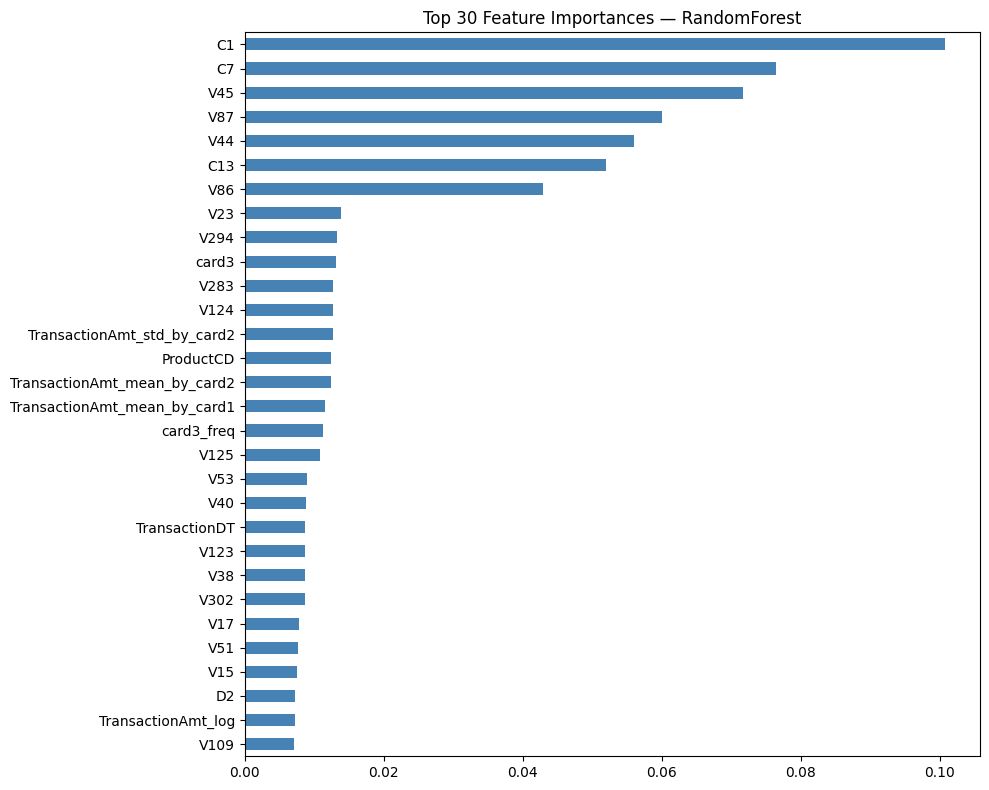


Features before : 237
Features after  : 100
🏃 View run RandomForest_Feature_Selection at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/a4d9edf541de4bfbb9ef0cda700110a6
🧪 View experiment at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


In [11]:
with mlflow.start_run(run_name="RandomForest_Feature_Selection"):

    n_before = train.shape[1]

    # Method 1: Variance Threshold
    vt           = VarianceThreshold(threshold=0.01)
    vt.fit(train)
    low_var_cols = train.columns[~vt.get_support()].tolist()
    train.drop(columns=low_var_cols, inplace=True)
    test.drop(columns=[c for c in low_var_cols if c in test.columns], inplace=True)
    print(f"Removed by VarianceThreshold : {len(low_var_cols)}")

    # Method 2: Correlation Filter
    corr_matrix    = train.corr().abs()
    upper          = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
    train.drop(columns=high_corr_cols, inplace=True)
    test.drop(columns=[c for c in high_corr_cols if c in test.columns], inplace=True)
    print(f"Removed by Correlation Filter: {len(high_corr_cols)}")

    # Method 3: SelectKBest — mutual information
    skb      = SelectKBest(score_func=mutual_info_classif, k=min(200, train.shape[1]))
    skb.fit(train, y)
    skb_mask = skb.get_support()
    skb_drop = train.columns[~skb_mask].tolist()
    train    = train[train.columns[skb_mask]]
    test     = test[[c for c in train.columns if c in test.columns]]
    print(f"Removed by SelectKBest       : {len(skb_drop)}")

    # Method 4: RandomForest Feature Importance — keep top 100
    quick_rf     = RandomForestClassifier(n_estimators=100, max_depth=8,
                                           random_state=42, n_jobs=-1)
    quick_rf.fit(train, y)
    importances  = pd.Series(quick_rf.feature_importances_, index=train.columns)
    top_features = importances.nlargest(100).index.tolist()
    train        = train[top_features]
    test         = test[[c for c in top_features if c in test.columns]]
    print(f"Kept top 100 by rf importance")

    n_after = train.shape[1]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    importances[top_features[:30]].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title("Top 30 Feature Importances — RandomForest")
    plt.tight_layout()
    plt.savefig("xrf_feature_importance.png")
    plt.show()

    mlflow.log_param("variance_threshold",    0.01)
    mlflow.log_param("correlation_threshold", 0.95)
    mlflow.log_param("selectkbest_k",         200)
    mlflow.log_param("selectkbest_method",    "mutual_info_classif")
    mlflow.log_param("top_k_importance",      100)
    mlflow.log_metric("features_before_selection", n_before)
    mlflow.log_metric("removed_low_variance",      len(low_var_cols))
    mlflow.log_metric("removed_high_corr",         len(high_corr_cols))
    mlflow.log_metric("removed_selectkbest",       len(skb_drop))
    mlflow.log_metric("features_after_selection",  n_after)
    mlflow.log_artifact("xrf_feature_importance.png")

    print(f"\nFeatures before : {n_before}")
    print(f"Features after  : {n_after}")

In [12]:
def run_cv_rf(params, run_name, n_splits=5):
    skf             = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_train_aucs = []
    fold_val_aucs   = []

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        for fold, (tr_idx, val_idx) in enumerate(skf.split(train, y)):
            X_tr,  X_val = train.iloc[tr_idx], train.iloc[val_idx]
            y_tr,  y_val = y.iloc[tr_idx],     y.iloc[val_idx]

            model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)

            train_auc = roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1])
            val_auc   = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

            fold_train_aucs.append(train_auc)
            fold_val_aucs.append(val_auc)

            mlflow.log_metric(f"fold_{fold+1}_train_auc", train_auc)
            mlflow.log_metric(f"fold_{fold+1}_val_auc",   val_auc)
            print(f"  Fold {fold+1} → Train: {train_auc:.4f} | Val: {val_auc:.4f} | Gap: {train_auc-val_auc:.4f}")

        mean_train = np.mean(fold_train_aucs)
        mean_val   = np.mean(fold_val_aucs)
        gap        = mean_train - mean_val

        mlflow.log_metric("mean_train_auc", mean_train)
        mlflow.log_metric("mean_val_auc",   mean_val)
        mlflow.log_metric("overfit_gap",    gap)

        status = "OVERFITTING" if gap > 0.05 else "UNDERFITTING" if mean_val < 0.75 else "HEALTHY"
        print(f"\n  Mean Train AUC : {mean_train:.4f}")
        print(f"  Mean Val AUC   : {mean_val:.4f}")
        print(f"  Overfit Gap    : {gap:.4f} → {status}")

    return mean_val

In [13]:
underfit_params = {
    'n_estimators': 10,
    'max_depth':     2,
    'max_features': 0.1,
}
run_cv_rf(underfit_params, run_name="RandomForest_Underfitted")

  Fold 1 → Train: 0.7746 | Val: 0.7797 | Gap: -0.0051
  Fold 2 → Train: 0.7740 | Val: 0.7797 | Gap: -0.0057
  Fold 3 → Train: 0.7705 | Val: 0.7623 | Gap: 0.0083
  Fold 4 → Train: 0.7722 | Val: 0.7742 | Gap: -0.0020
  Fold 5 → Train: 0.7701 | Val: 0.7628 | Gap: 0.0074

  Mean Train AUC : 0.7723
  Mean Val AUC   : 0.7717
  Overfit Gap    : 0.0006 → HEALTHY
🏃 View run RandomForest_Underfitted at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/08c7e78690ca449299e771724e7d209a
🧪 View experiment at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


np.float64(0.7717239129620663)

## Underfitting Analysis

**Observation:** Both train and val AUC are low.

**Root cause:**
- `max_depth=2` limits each tree to 2 splits — decision stumps with no complexity.
- `max_features=0.1` means each tree only sees 10% of features — not enough signal.
- 10 trees is far too few for a Random Forest to build a reliable ensemble.

**Conclusion:** High bias. The model has insufficient capacity.
Fix: increase max_depth, n_estimators, and max_features.

In [14]:
overfit_params = {
    'n_estimators': 500,
    'max_depth':   None,   # unlimited depth — will memorize
    'max_features':  1.0,  # use all features
    'min_samples_leaf': 1, # allow single-sample leaves
}
run_cv_rf(overfit_params, run_name="RandomForest_Overfitted")

KeyboardInterrupt: 

## Overfitting Analysis

**Observation:** Train AUC near 1.0, val AUC significantly lower.

**Root cause:**
- `max_depth=None` allows unlimited tree growth — trees memorize the training set.
- `min_samples_leaf=1` permits leaves with a single sample — pure memorization.
- `max_features=1.0` means each tree sees all features, reducing diversity in the ensemble.

**Note:** Random Forests are naturally more resistant to overfitting than
boosting methods due to bagging, but with no depth limit and 1-sample leaves,
even RF will overfit noticeably.

**Conclusion:** Reduce depth, increase min_samples_leaf, tune max_features.

In [16]:
tuned_params_rf = {
    'n_estimators':     300,
    'max_depth':         15,
    'max_features':    'sqrt',
    'min_samples_leaf':   4,
    'min_samples_split':  8,
    'class_weight':  'balanced',
}
run_cv_rf(tuned_params_rf, run_name="RandomForest_Tuned")

  Fold 1 → Train: 0.9742 | Val: 0.9369 | Gap: 0.0372
  Fold 2 → Train: 0.9747 | Val: 0.9401 | Gap: 0.0346
  Fold 3 → Train: 0.9747 | Val: 0.9367 | Gap: 0.0379
  Fold 4 → Train: 0.9748 | Val: 0.9365 | Gap: 0.0383
  Fold 5 → Train: 0.9744 | Val: 0.9368 | Gap: 0.0376

  Mean Train AUC : 0.9746
  Mean Val AUC   : 0.9374
  Overfit Gap    : 0.0371 → HEALTHY
🏃 View run RandomForest_Tuned at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/1750d3095e2f4f4294253e9749b9f610
🧪 View experiment at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


np.float64(0.9374090320696358)

In [21]:
class  RandomForestFraudPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, null_thresh=0.5, top_k=100):
        self.null_thresh = null_thresh
        self.top_k       = top_k

    def fit(self, X, y=None):
        X = X.copy()
        for col in ['TransactionID', 'isFraud']:
            if col in X.columns:
                X.drop(columns=[col], inplace=True)

        # Null cols
        null_pct             = X.isnull().mean()
        self.high_null_cols_ = null_pct[null_pct > self.null_thresh].index.tolist()
        X.drop(columns=self.high_null_cols_, inplace=True)

        # Constant cols
        self.const_cols_ = [c for c in X.columns if X[c].nunique() <= 1]
        X.drop(columns=self.const_cols_, inplace=True)

        # Label encoders
        self.cat_cols_       = X.select_dtypes(include='object').columns.tolist()
        self.label_encoders_ = {}
        for col in self.cat_cols_:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.label_encoders_[col] = le
            X[col] = le.transform(X[col].astype(str))

        # Medians
        num_cols      = X.select_dtypes(include=np.number).columns.tolist()
        self.medians_ = X[num_cols].median()
        X[num_cols]   = X[num_cols].fillna(self.medians_)

        # Frequency maps
        self.freq_maps_ = {}
        for col in ['card1','card2','card3','card5','addr1','addr2']:
            if col in X.columns:
                self.freq_maps_[col] = X[col].value_counts().to_dict()

        # Aggregation maps
        self.agg_maps_ = {}
        for col in ['card1','card2']:
            if col in X.columns:
                self.agg_maps_[col] = X.groupby(col)['TransactionAmt'].agg(['mean','std'])

        # Email encoder
        self.has_email_ = 'P_emaildomain' in X.columns
        if self.has_email_:
            X['P_email_suffix'] = X['P_emaildomain'].astype(str).apply(
                lambda x: x.split('.')[-1] if '.' in str(x) else 'unknown'
            )
            self.le_email_ = LabelEncoder()
            self.le_email_.fit(X['P_email_suffix'].astype(str))

        # Card+addr freq
        self.has_card_addr_ = 'card1' in X.columns and 'addr1' in X.columns
        if self.has_card_addr_:
            X['card1_addr1']      = X['card1'].astype(str) + '_' + X['addr1'].astype(str)
            self.card_addr_freq_  = X['card1_addr1'].value_counts().to_dict()

        # Get top features from a quick model
        X_t = self._apply_fe(X)
        X_t.fillna(-999, inplace=True)
        qrf = RandomForestClassifier(
            n_estimators=100,
            max_depth=4,
            random_state=42,
            n_jobs=-1
        )
        
        qrf.fit(X_t, y)
        
        imp = pd.Series(qrf.feature_importances_, index=X_t.columns)
        self.top_features_ = imp.nlargest(self.top_k).index.tolist()

        return self

    def _apply_fe(self, X):
        if 'TransactionDT' in X.columns:
            X['hour']        = (X['TransactionDT'] / 3600) % 24
            X['day_of_week'] = (X['TransactionDT'] / (3600*24)) % 7
            X['week']        = (X['TransactionDT'] / (3600*24*7)) % 52
        if 'TransactionAmt' in X.columns:
            X['TransactionAmt_log']     = np.log1p(X['TransactionAmt'])
            X['TransactionAmt_cents']   = X['TransactionAmt'] - X['TransactionAmt'].astype(int)
            X['TransactionAmt_isround'] = (X['TransactionAmt_cents'] == 0).astype(int)
        for col, freq_map in self.freq_maps_.items():
            if col in X.columns:
                X[f'{col}_freq'] = X[col].map(freq_map).fillna(0)
        for col, agg in self.agg_maps_.items():
            if col in X.columns:
                X[f'TransactionAmt_mean_by_{col}'] = X[col].map(agg['mean'])
                X[f'TransactionAmt_std_by_{col}']  = X[col].map(agg['std'])
        if 'TransactionAmt_mean_by_card1' in X.columns:
            X['amt_vs_card_mean'] = X['TransactionAmt'] / (X['TransactionAmt_mean_by_card1'] + 1)
        if self.has_email_ and 'P_emaildomain' in X.columns:
            X['P_email_suffix'] = X['P_emaildomain'].astype(str).apply(
                lambda x: x.split('.')[-1] if '.' in str(x) else 'unknown'
            )
            classes = set(self.le_email_.classes_)
            X['P_email_suffix'] = self.le_email_.transform(
                X['P_email_suffix'].astype(str).apply(lambda x: x if x in classes else self.le_email_.classes_[0])
            )
        if 'P_emaildomain' in X.columns and 'R_emaildomain' in X.columns:
            X['email_match'] = (X['P_emaildomain'] == X['R_emaildomain']).astype(int)
        if self.has_card_addr_ and 'card1' in X.columns and 'addr1' in X.columns:
            X['card1_addr1']      = X['card1'].astype(str) + '_' + X['addr1'].astype(str)
            X['card1_addr1_freq'] = X['card1_addr1'].map(self.card_addr_freq_).fillna(0)
            X.drop(columns=['card1_addr1'], inplace=True)
        return X

    def transform(self, X):
        X = X.copy()
        for col in ['TransactionID', 'isFraud']:
            if col in X.columns:
                X.drop(columns=[col], inplace=True)
        X.drop(columns=[c for c in self.high_null_cols_ if c in X.columns], inplace=True)
        X.drop(columns=[c for c in self.const_cols_     if c in X.columns], inplace=True)
        for col, le in self.label_encoders_.items():
            if col in X.columns:
                classes = set(le.classes_)
                X[col]  = le.transform(
                    X[col].astype(str).apply(lambda x: x if x in classes else le.classes_[0])
                )
        for col in self.medians_.index:
            if col in X.columns:
                X[col] = X[col].fillna(self.medians_[col])
        X = self._apply_fe(X)
        X.fillna(-999, inplace=True)
        available = [c for c in self.top_features_ if c in X.columns]
        return X[available]

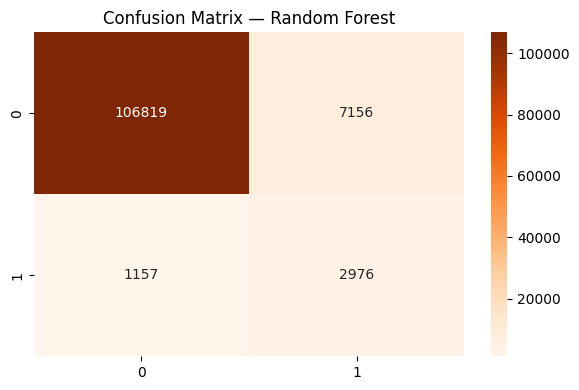

2026/05/08 17:39:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 17:39:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'RandomForest_FraudDetection'.
2026/05/08 17:40:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest_FraudDetection, version 1
Created version '1' of model 'RandomForest_FraudDetection'.


Val AUC : 0.9172
Pipeline saved to Model Registry ✓
🏃 View run RandomForest_Best_Model at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3/runs/5236fda2eae242199e596cf549a791c0
🧪 View experiment at: https://dagshub.com/aband22/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/3


In [22]:
with mlflow.start_run(run_name="RandomForest_Best_Model"):

    mlflow.log_params(tuned_params_rf)

    raw_train_data = pd.merge(train_transaction, train_identity,
                               on='TransactionID', how='left')
    raw_y          = raw_train_data['isFraud'].copy()

    X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
        raw_train_data, raw_y, test_size=0.2, random_state=42, stratify=raw_y
    )

    pipeline_rf = Pipeline([
        ('preprocessor', RandomForestFraudPreprocessor(
            null_thresh=0.5,
            top_k=100
        )),
        ('model', RandomForestClassifier(
            **tuned_params_rf,
            random_state=42,
            n_jobs=-1
        ))
    ])
    pipeline_rf.fit(X_tr_raw, y_tr)

    val_preds  = pipeline_rf.predict_proba(X_val_raw)[:, 1]
    val_labels = pipeline_rf.predict(X_val_raw)
    val_auc    = roc_auc_score(y_val, val_preds)
    val_f1     = f1_score(y_val, val_labels)
    val_prec   = precision_score(y_val, val_labels)
    val_rec    = recall_score(y_val, val_labels)

    mlflow.log_metric("val_auc",       val_auc)
    mlflow.log_metric("val_f1",        val_f1)
    mlflow.log_metric("val_precision", val_prec)
    mlflow.log_metric("val_recall",    val_rec)

    cm = confusion_matrix(y_val, val_labels)
    fig, ax = plt.subplots(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax)
    ax.set_title("Confusion Matrix — Random Forest")
    plt.tight_layout()
    plt.savefig("rf_confusion_matrix.png")
    mlflow.log_artifact("rf_confusion_matrix.png")
    plt.show()

    pipeline_rf.fit(raw_train_data.drop(columns=['isFraud']), raw_y)

    mlflow.sklearn.log_model(
        pipeline_rf,
        artifact_path="rf_pipeline",
        registered_model_name="RandomForest_FraudDetection"
    )

    print(f"Val AUC : {val_auc:.4f}")
    print("Pipeline saved to Model Registry ✓")